In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
pd.set_option('display.max_columns', None)
    


Le but est d'avoir un modèle pouvant prédire la finalité d'un sinistre auto, interessant pour connaitre la prime. 

In [ ]:
chemin_lieu = '/Users/hugoseumen/Desktop/Cours M2 Actuariat/Projet ML/lieux-2022.csv'
chemin_usager = '/Users/hugoseumen/Desktop/Cours M2 Actuariat/Projet ML/usagers-2022 (1).csv'
chemin_vehicule = '/Users/hugoseumen/Desktop/Cours M2 Actuariat/Projet ML/vehicules-2022.csv'
chemin_caracteristique = '/Users/hugoseumen/Desktop/Cours M2 Actuariat/Projet ML/carcteristiques-2022.csv'


df_lieu = pd.read_csv(chemin_lieu, header=0, sep= ';', decimal=',')
df_usager = pd.read_csv(chemin_usager, header=0, sep= ';', decimal=',')
df_vehicule = pd.read_csv(chemin_vehicule, header=0, sep= ';', decimal=',')
df_caracteristique = pd.read_csv(chemin_caracteristique, header=0, sep= ';', decimal=',')

df_lieu.head()



/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (6) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202200000001,4,TEIL(vieille route du),0,NaN,2,2,0,1,(1),(1),1,NaN,-1.0,1,0,1,50
1,202200000002,4,NaN,0,NaN,2,2,0,1,(1),(1),1,NaN,-1.0,1,0,1,50
2,202200000003,3,ROND POINT DE BREZILLET,0,NaN,-1,2,0,1,0,0,1,NaN,-1.0,1,5,1,50
3,202200000004,4,QUATORZE JUILLET (RUE DU),0,NaN,1,1,0,2,(1),(1),1,NaN,4.0,1,0,1,30
4,202200000005,3,ROUTE DE JEAN MOULIN-RN 538,0,NaN,2,2,0,1,8,0,1,NaN,-1.0,1,0,1,80


In [4]:
np.shape(df_lieu)

(55302, 18)

In [5]:
df_carac = df_caracteristique.rename(columns={'Accident_Id':'Num_Acc'})
df_carac.head()


,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),44.559420,4.725720
1,202200000002,20,10,2022,08:34,1,25,25204,2,3,1,3,Miranda,46.925810,6.346200
2,202200000003,20,10,2022,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,48.493162,-2.760439
3,202200000004,20,10,2022,18:00,1,16,16102,2,3,8,6,LOHMEYER (RUE),45.692652,-0.326290
4,202200000005,19,10,2022,11:45,1,13,13103,1,1,1,2,ROUTE DE JEAN MOULIN-RN 538,43.675579,5.092703


In [6]:
np.shape(df_caracteristique)

(55302, 15)

In [7]:
df_usager.head()

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202200000001,1 099 700,813 952,A01,1,1,3,1,2008.0,5,2,8,-1,-1,-1,-1
1,202200000001,1 099 701,813 953,B01,1,1,1,1,1948.0,5,1,8,-1,-1,-1,-1
2,202200000002,1 099 698,813 950,B01,1,1,4,1,1988.0,9,1,0,-1,0,0,-1
3,202200000002,1 099 699,813 951,A01,1,1,1,1,1970.0,4,1,0,-1,0,0,-1
4,202200000003,1 099 696,813 948,A01,1,1,1,1,2002.0,0,1,0,-1,-1,-1,-1


In [8]:
np.shape(df_usager)

(126662, 16)

In [9]:
df_vehicule.head()


,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202200000001,813 952,A01,1,2,0,2,1,9,1,NaN
1,202200000001,813 953,B01,1,7,0,2,2,1,1,NaN
2,202200000002,813 950,B01,2,7,0,2,8,15,1,NaN
3,202200000002,813 951,A01,2,10,0,2,1,1,1,NaN
4,202200000003,813 948,A01,2,7,0,2,1,2,1,NaN


In [10]:
np.shape(df_vehicule)

(94493, 11)

In [11]:
df_carac_lieu = pd.merge(df_carac,df_lieu, on = 'Num_Acc', how='left')
df_carac_lieu_usager = pd.merge(df_carac_lieu, df_usager, on = 'Num_Acc', how='right')
df_final = pd.merge(df_carac_lieu_usager, df_vehicule, on = 'id_vehicule', how='left')
df_final

,Num_Acc_x,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma,id_usager,id_vehicule,num_veh_x,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,Num_Acc_y,num_veh_y,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),44.559420,4.725720,4,TEIL(vieille route du),0,NaN,2,2,0,1,(1),(1),1,NaN,-1.0,1,0,1,50,1 099 700,813 952,A01,1,1,3,1,2008.0,5,2,8,-1,-1,-1,-1,202200000001,A01,1,2,0,2,1,9,1,NaN
1,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),44.559420,4.725720,4,TEIL(vieille route du),0,NaN,2,2,0,1,(1),(1),1,NaN,-1.0,1,0,1,50,1 099 701,813 953,B01,1,1,1,1,1948.0,5,1,8,-1,-1,-1,-1,202200000001,B01,1,7,0,2,2,1,1,NaN
2,202200000002,20,10,2022,08:34,1,25,25204,2,3,1,3,Miranda,46.925810,6.346200,4,NaN,0,NaN,2,2,0,1,(1),(1),1,NaN,-1.0,1,0,1,50,1 099 698,813 950,B01,1,1,4,1,1988.0,9,1,0,-1,0,0,-1,202200000002,B01,2,7,0,2,8,15,1,NaN
3,202200000002,20,10,2022,08:34,1,25,25204,2,3,1,3,Miranda,46.925810,6.346200,4,NaN,0,NaN,2,2,0,1,(1),(1),1,NaN,-1.0,1,0,1,50,1 099 699,813 951,A01,1,1,1,1,1970.0,4,1,0,-1,0,0,-1,202200000002,A01,2,10,0,2,1,1,1,NaN
4,202200000003,20,10,2022,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,48.493162,-2.760439,3,ROND POINT DE BREZILLET,0,NaN,-1,2,0,1,0,0,1,NaN,-1.0,1,5,1,50,1 099 696,813 948,A01,1,1,1,1,2002.0,0,1,0,-1,-1,-1,-1,202200000003,A01,2,7,0,2,1,2,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126657,202200055301,1,1,2022,08:40,1,81,81099,1,3,1,3,Chemin Toulze,43.927265,1.915637,3,18,-1,D,2,2,0,1,30,125,1,NaN,-1.0,1,0,1,80,968 230,715 631,A01,1,1,1,2,2002.0,5,1,-1,-1,0,0,-1,202200055301,A01,2,7,0,0,8,19,1,NaN
126658,202200055301,1,1,2022,08:40,1,81,81099,1,3,1,3,Chemin Toulze,43.927265,1.915637,3,18,-1,D,2,2,0,1,30,125,1,NaN,-1.0,1,0,1,80,968 231,715 631,A01,8,2,3,2,2004.0,5,1,-1,-1,0,0,-1,202200055301,A01,2,7,0,0,8,19,1,NaN
126659,202200055301,1,1,2022,08:40,1,81,81099,1,3,1,3,Chemin Toulze,43.927265,1.915637,3,18,-1,D,2,2,0,1,30,125,1,NaN,-1.0,1,0,1,80,968 232,715 632,B01,1,1,4,2,1953.0,5,1,-1,-1,0,0,-1,202200055301,B01,2,7,0,2,1,1,1,NaN
126660,202200055302,1,3,2022,16:55,1,41,41018,2,1,1,2,RD956 - Pont Charles De Gaulle,47.594404,1.353329,3,NaN,-1,NaN,3,4,0,1,(1),(1),1,NaN,4.0,1,0,1,70,968 228,715 629,A01,1,1,3,1,1992.0,1,2,6,-1,-1,-1,-1,202200055302,A01,1,33,0,2,1,1,1,NaN


In [12]:
df_final['grav'].value_counts()


 1    53630
 4    49981
 3    19260
 2     3550
-1      241
Name: grav, dtype: int64

In [13]:
df = df_final.loc[~ ((df_final['grav'] == -1) | (df_final['vma'] == -1) | (df_final['vma']> 200))]
df.shape

(124530, 57)

In [14]:
df.columns


Index(['Num_Acc_x', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg',
       'int', 'atm', 'col', 'adr', 'lat', 'long', 'catr', 'voie', 'v1', 'v2',
       'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout',
       'surf', 'infra', 'situ', 'vma', 'id_usager', 'id_vehicule', 'num_veh_x',
       'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2',
       'secu3', 'locp', 'actp', 'etatp', 'Num_Acc_y', 'num_veh_y', 'senc',
       'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'occutc'],
      dtype='object')

# Nettoyage de données 

In [15]:
df['date_heure'] = pd.to_datetime(df[['an', 'mois', 'jour']].astype(str).agg('-'.join, axis=1) + ' ' + df['hrmn'])

#on converti dans un format date heure pour rassemebler nos colonnes temporel en une seul et unique colonne

<ipython-input-15-60c7d837c054>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_heure'] = pd.to_datetime(df[['an', 'mois', 'jour']].astype(str).agg('-'.join, axis=1) + ' ' + df['hrmn'])


In [16]:
df['age_victime'] = df['an'] - df['an_nais']

<ipython-input-16-c19ab9d8a1a4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_victime'] = df['an'] - df['an_nais']


In [17]:
df.head()

inutile = ['Num_Acc_x', 'adr', 'com', 'agg', 'id_usager', 'voie', 'v1', 'v2', 'pr', 'pr1', 
           'id_vehicule', 'num_veh_x', 'Num_Acc_y', 'num_veh_y', 'jour', 'mois', 'hrmn', 'an', 'an_nais']

col_utile = df.columns[~ (df.columns.isin(inutile))]

df_1 = df[col_utile]

df_1.head()

,lum,dep,int,atm,col,lat,long,catr,circ,nbv,vosp,prof,plan,lartpc,larrout,surf,infra,situ,vma,place,catu,grav,sexe,trajet,secu1,secu2,secu3,locp,actp,etatp,senc,catv,obs,obsm,choc,manv,motor,occutc,date_heure,age_victime
0,1,26,3,1,3,44.559420,4.725720,4,2,2,0,1,1,NaN,-1.0,1,0,1,50,1,1,3,1,5,2,8,-1,-1,-1,-1,1,2,0,2,1,9,1,NaN,2022-10-19 16:15:00,14.0
1,1,26,3,1,3,44.559420,4.725720,4,2,2,0,1,1,NaN,-1.0,1,0,1,50,1,1,1,1,5,1,8,-1,-1,-1,-1,1,7,0,2,2,1,1,NaN,2022-10-19 16:15:00,74.0
2,1,25,3,1,3,46.925810,6.346200,4,2,2,0,1,1,NaN,-1.0,1,0,1,50,1,1,4,1,9,1,0,-1,0,0,-1,2,7,0,2,8,15,1,NaN,2022-10-20 08:34:00,34.0
3,1,25,3,1,3,46.925810,6.346200,4,2,2,0,1,1,NaN,-1.0,1,0,1,50,1,1,1,1,4,1,0,-1,0,0,-1,2,10,0,2,1,1,1,NaN,2022-10-20 08:34:00,52.0
4,1,22,6,1,2,48.493162,-2.760439,3,-1,2,0,1,1,NaN,-1.0,1,5,1,50,1,1,1,1,0,1,0,-1,-1,-1,-1,2,7,0,2,1,2,1,NaN,2022-10-20 17:15:00,20.0


In [18]:
df_1.dtypes.value_counts()

int64             30
float64            6
object             3
datetime64[ns]     1
dtype: int64

In [19]:
num_col = ['lat', 'long', 'lartpc', 'vma' , 'occutc', 'larrout', 'nbv']
cat_col = df_1.columns[~(df_1.columns.isin(num_col + ['date_heure']))]

df_1[cat_col] = df_1[cat_col].astype('category')


/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:3191: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


In [20]:
df_1.dtypes.astype(str).value_counts()

category          32
float64            5
int64              1
datetime64[ns]     1
object             1
dtype: int64

Analyse des NAN 

In [172]:
np.sum(df_1.isna(), axis=0)/len(df_1)

lum            0.000000
dep            0.000000
int            0.000000
atm            0.000000
col            0.000000
lat            0.000000
long           0.000000
catr           0.000000
circ           0.000000
nbv            0.000000
vosp           0.000000
prof           0.000000
plan           0.000000
lartpc         0.999510
larrout        0.000000
surf           0.000000
infra          0.000000
situ           0.000000
vma            0.000000
place          0.000000
catu           0.000000
grav           0.000000
sexe           0.000000
trajet         0.000000
secu1          0.000000
secu2          0.000000
secu3          0.000000
locp           0.000000
actp           0.000000
etatp          0.000000
senc           0.000000
catv           0.000000
obs            0.000000
obsm           0.000000
choc           0.000000
manv           0.000000
motor          0.000000
occutc         0.985899
date_heure     0.000000
age_victime    0.020991
dtype: float64

In [22]:
#on enleève les colonne avec plus de 98% de NAN

col_full = (np.sum(df_1.isna(), axis=0)/len(df_1))<0.98

df_2 = df_1[df_1.columns[col_full]]
df_2.head()

,lum,dep,int,atm,col,lat,long,catr,circ,nbv,vosp,prof,plan,larrout,surf,infra,situ,vma,place,catu,grav,sexe,trajet,secu1,secu2,secu3,locp,actp,etatp,senc,catv,obs,obsm,choc,manv,motor,date_heure,age_victime
0,1,26,3,1,3,44.559420,4.725720,4,2,2,0,1,1,-1.0,1,0,1,50,1,1,3,1,5,2,8,-1,-1,-1,-1,1,2,0,2,1,9,1,2022-10-19 16:15:00,14.0
1,1,26,3,1,3,44.559420,4.725720,4,2,2,0,1,1,-1.0,1,0,1,50,1,1,1,1,5,1,8,-1,-1,-1,-1,1,7,0,2,2,1,1,2022-10-19 16:15:00,74.0
2,1,25,3,1,3,46.925810,6.346200,4,2,2,0,1,1,-1.0,1,0,1,50,1,1,4,1,9,1,0,-1,0,0,-1,2,7,0,2,8,15,1,2022-10-20 08:34:00,34.0
3,1,25,3,1,3,46.925810,6.346200,4,2,2,0,1,1,-1.0,1,0,1,50,1,1,1,1,4,1,0,-1,0,0,-1,2,10,0,2,1,1,1,2022-10-20 08:34:00,52.0
4,1,22,6,1,2,48.493162,-2.760439,3,-1,2,0,1,1,-1.0,1,5,1,50,1,1,1,1,0,1,0,-1,-1,-1,-1,2,7,0,2,1,2,1,2022-10-20 17:15:00,20.0


In [23]:
# pour l'age, on enlève les ligne où on a rien 

df_3 = df_2.loc[~ (df_2['age_victime'].isna())]

In [24]:
num_col


['lat', 'long', 'lartpc', 'vma', 'occutc', 'larrout', 'nbv']

In [25]:
sum(df_3['larrout']==-1)/len(df_3)
# 93% de " -1" sur la variable traitant la largeur de la route

0.9351274648118376

In [26]:

df_4 = df_3.copy()
df_4['nbv'] = pd.to_numeric(df_4['nbv'], errors='coerce')
df_5 = df_4.loc[~ (df_4['nbv'].isna() | df_4['nbv']<0),: ]
df_6= df_5.copy()

df_6.loc[(df_6['catr'] == 1) & (df_6['nbv'] >= 4), ['nbv']] /= 2

df_6.head()

,lum,dep,int,atm,col,lat,long,catr,circ,nbv,vosp,prof,plan,larrout,surf,infra,situ,vma,place,catu,grav,sexe,trajet,secu1,secu2,secu3,locp,actp,etatp,senc,catv,obs,obsm,choc,manv,motor,date_heure,age_victime
0,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,-1.0,1,0,1,50,1,1,3,1,5,2,8,-1,-1,-1,-1,1,2,0,2,1,9,1,2022-10-19 16:15:00,14.0
1,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,-1.0,1,0,1,50,1,1,1,1,5,1,8,-1,-1,-1,-1,1,7,0,2,2,1,1,2022-10-19 16:15:00,74.0
2,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,-1.0,1,0,1,50,1,1,4,1,9,1,0,-1,0,0,-1,2,7,0,2,8,15,1,2022-10-20 08:34:00,34.0
3,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,-1.0,1,0,1,50,1,1,1,1,4,1,0,-1,0,0,-1,2,10,0,2,1,1,1,2022-10-20 08:34:00,52.0
4,1,22,6,1,2,48.493162,-2.760439,3,-1,2.0,0,1,1,-1.0,1,5,1,50,1,1,1,1,0,1,0,-1,-1,-1,-1,2,7,0,2,1,2,1,2022-10-20 17:15:00,20.0


L'idée de départ était de ne pas supprimmer la colonne 'larrout' car on estimait qu'elle a son importance. Or elle est pratiquement uniquement rempli de -1. e plus cette colonne est à priori CL de la collonne 'nbv' donc on peut la supprimmer. 

In [27]:
df_7 = df_6.drop(columns= ['larrout'])
df_8 = df_7.loc[ (df_7['nbv']>0) & (df_7['nbv']<5)]
df_8.head()

,lum,dep,int,atm,col,lat,long,catr,circ,nbv,vosp,prof,plan,surf,infra,situ,vma,place,catu,grav,sexe,trajet,secu1,secu2,secu3,locp,actp,etatp,senc,catv,obs,obsm,choc,manv,motor,date_heure,age_victime
0,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,1,0,1,50,1,1,3,1,5,2,8,-1,-1,-1,-1,1,2,0,2,1,9,1,2022-10-19 16:15:00,14.0
1,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,1,0,1,50,1,1,1,1,5,1,8,-1,-1,-1,-1,1,7,0,2,2,1,1,2022-10-19 16:15:00,74.0
2,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,1,0,1,50,1,1,4,1,9,1,0,-1,0,0,-1,2,7,0,2,8,15,1,2022-10-20 08:34:00,34.0
3,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,1,0,1,50,1,1,1,1,4,1,0,-1,0,0,-1,2,10,0,2,1,1,1,2022-10-20 08:34:00,52.0
4,1,22,6,1,2,48.493162,-2.760439,3,-1,2.0,0,1,1,1,5,1,50,1,1,1,1,0,1,0,-1,-1,-1,-1,2,7,0,2,1,2,1,2022-10-20 17:15:00,20.0


In [28]:
for col in df_8.select_dtypes('category') : 
    print ( f'{col :-<50} {df_8[col].unique()}')

lum----------------------------------------------- [1, 5, 3, 2, 4]
Categories (5, int64): [1, 5, 3, 2, 4]
dep----------------------------------------------- ['26', '25', '22', '16', '13', ..., '90', '23', '977', '978', '975']
Length: 107
Categories (107, object): ['26', '25', '22', '16', ..., '23', '977', '978', '975']
int----------------------------------------------- [3, 6, 1, 2, 9, 7, 4, 8, 5, -1]
Categories (10, int64): [3, 6, 1, 2, ..., 4, 8, 5, -1]
atm----------------------------------------------- [1, 8, 2, 9, 3, 5, 7, 6, 4]
Categories (9, int64): [1, 8, 2, 9, ..., 5, 7, 6, 4]
col----------------------------------------------- [3, 2, 6, 1, -1, 4, 7, 5]
Categories (8, int64): [3, 2, 6, 1, -1, 4, 7, 5]
catr---------------------------------------------- [4, 3, 1, 2, 5, 7, 9, 6]
Categories (8, int64): [4, 3, 1, 2, 5, 7, 9, 6]
circ---------------------------------------------- [2, -1, 1, 3, 4]
Categories (5, int64): [2, -1, 1, 3, 4]
vosp---------------------------------------------- 

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/pandas/io/formats/format.py:1405: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  for val, m in zip(values.ravel(), mask.ravel())
/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/pandas/io/formats/format.py:1405: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  for val, m in zip(values.ravel(), mask.ravel())


In [29]:
df_8.head()

,lum,dep,int,atm,col,lat,long,catr,circ,nbv,vosp,prof,plan,surf,infra,situ,vma,place,catu,grav,sexe,trajet,secu1,secu2,secu3,locp,actp,etatp,senc,catv,obs,obsm,choc,manv,motor,date_heure,age_victime
0,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,1,0,1,50,1,1,3,1,5,2,8,-1,-1,-1,-1,1,2,0,2,1,9,1,2022-10-19 16:15:00,14.0
1,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,1,0,1,50,1,1,1,1,5,1,8,-1,-1,-1,-1,1,7,0,2,2,1,1,2022-10-19 16:15:00,74.0
2,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,1,0,1,50,1,1,4,1,9,1,0,-1,0,0,-1,2,7,0,2,8,15,1,2022-10-20 08:34:00,34.0
3,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,1,0,1,50,1,1,1,1,4,1,0,-1,0,0,-1,2,10,0,2,1,1,1,2022-10-20 08:34:00,52.0
4,1,22,6,1,2,48.493162,-2.760439,3,-1,2.0,0,1,1,1,5,1,50,1,1,1,1,0,1,0,-1,-1,-1,-1,2,7,0,2,1,2,1,2022-10-20 17:15:00,20.0


In [30]:
df_8['année'] = df_8['date_heure'].dt.year
df_8['mois'] = df_8['date_heure'].dt.month
df_8['jour'] = df_8['date_heure'].dt.day
df_8['jour_semaine'] = df_8['date_heure'].dt.weekday  # Lundi=0, Dimanche=6
df_8['heure'] = df_8['date_heure'].dt.hour
df_8['minute'] = df_8['date_heure'].dt.minute
df_8['heure_sin'] = np.sin(2 * np.pi * df_8['heure'] / 24)
df_8['heure_cos'] = np.cos(2 * np.pi * df_8['heure'] / 24)

df_9 = df_8.drop(columns=['date_heure'])

<ipython-input-30-42623aecacde>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8['année'] = df_8['date_heure'].dt.year
<ipython-input-30-42623aecacde>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_8['mois'] = df_8['date_heure'].dt.month
<ipython-input-30-42623aecacde>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stab

In [31]:
df_9.head()

,lum,dep,int,atm,col,lat,long,catr,circ,nbv,vosp,prof,plan,surf,infra,situ,vma,place,catu,grav,sexe,trajet,secu1,secu2,secu3,locp,actp,etatp,senc,catv,obs,obsm,choc,manv,motor,age_victime,année,mois,jour,jour_semaine,heure,minute,heure_sin,heure_cos
0,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,1,0,1,50,1,1,3,1,5,2,8,-1,-1,-1,-1,1,2,0,2,1,9,1,14.0,2022,10,19,2,16,15,-0.866025,-0.500000
1,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,1,0,1,50,1,1,1,1,5,1,8,-1,-1,-1,-1,1,7,0,2,2,1,1,74.0,2022,10,19,2,16,15,-0.866025,-0.500000
2,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,1,0,1,50,1,1,4,1,9,1,0,-1,0,0,-1,2,7,0,2,8,15,1,34.0,2022,10,20,3,8,34,0.866025,-0.500000
3,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,1,0,1,50,1,1,1,1,4,1,0,-1,0,0,-1,2,10,0,2,1,1,1,52.0,2022,10,20,3,8,34,0.866025,-0.500000
4,1,22,6,1,2,48.493162,-2.760439,3,-1,2.0,0,1,1,1,5,1,50,1,1,1,1,0,1,0,-1,-1,-1,-1,2,7,0,2,1,2,1,20.0,2022,10,20,3,17,15,-0.965926,-0.258819


In [32]:
num_col

['lat', 'long', 'lartpc', 'vma', 'occutc', 'larrout', 'nbv']

In [33]:
df_10 = df_9[~ (df_9['grav'] == 2)]
df_10['sinistre']= (df_10['grav'] == 3) | (df_10['grav'] == 4)
df_10 = df_10.drop(columns=['grav', 'heure', 'minute','jour','mois','année'])

<ipython-input-33-e94965f5a22f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_10['sinistre']= (df_10['grav'] == 3) | (df_10['grav'] == 4)


In [34]:
df_10

,lum,dep,int,atm,col,lat,long,catr,circ,nbv,vosp,prof,plan,surf,infra,situ,vma,place,catu,sexe,trajet,secu1,secu2,secu3,locp,actp,etatp,senc,catv,obs,obsm,choc,manv,motor,age_victime,jour_semaine,heure_sin,heure_cos,sinistre
0,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,1,0,1,50,1,1,1,5,2,8,-1,-1,-1,-1,1,2,0,2,1,9,1,14.0,2,-0.866025,-0.500000,True
1,1,26,3,1,3,44.559420,4.725720,4,2,2.0,0,1,1,1,0,1,50,1,1,1,5,1,8,-1,-1,-1,-1,1,7,0,2,2,1,1,74.0,2,-0.866025,-0.500000,False
2,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,1,0,1,50,1,1,1,9,1,0,-1,0,0,-1,2,7,0,2,8,15,1,34.0,3,0.866025,-0.500000,True
3,1,25,3,1,3,46.925810,6.346200,4,2,2.0,0,1,1,1,0,1,50,1,1,1,4,1,0,-1,0,0,-1,2,10,0,2,1,1,1,52.0,3,0.866025,-0.500000,False
4,1,22,6,1,2,48.493162,-2.760439,3,-1,2.0,0,1,1,1,5,1,50,1,1,1,0,1,0,-1,-1,-1,-1,2,7,0,2,1,2,1,20.0,3,-0.965926,-0.258819,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126657,1,81,3,1,3,43.927265,1.915637,3,2,2.0,0,1,1,1,0,1,80,1,1,2,5,1,-1,-1,0,0,-1,2,7,0,0,8,19,1,20.0,5,0.866025,-0.500000,False
126658,1,81,3,1,3,43.927265,1.915637,3,2,2.0,0,1,1,1,0,1,80,8,2,2,5,1,-1,-1,0,0,-1,2,7,0,0,8,19,1,18.0,5,0.866025,-0.500000,True
126659,1,81,3,1,3,43.927265,1.915637,3,2,2.0,0,1,1,1,0,1,80,1,1,2,5,1,-1,-1,0,0,-1,2,7,0,2,1,1,1,69.0,5,0.866025,-0.500000,True
126660,1,41,1,1,2,47.594404,1.353329,3,3,4.0,0,1,1,1,0,1,70,1,1,1,1,2,6,-1,-1,-1,-1,1,33,0,2,1,1,1,30.0,1,-0.866025,-0.500000,True


# Graphes !!!!!

In [35]:
import plotly.express as px 


In [36]:
atm_mapping = {
    -1: "Non renseigné",
    1: "Normale",
    2: "Pluie légère",
    3: "Pluie forte",
    4: "Neige / grêle",
    5: "Brouillard / fumée",
    6: "Vent fort / tempête",
    7: "Temps éblouissant",
    8: "Temps couvert",
    9: "Autre"
}

# Appliquer le mapping dans un DataFrame (exemple)
df_10['atm_mapped'] = df_10['atm'].map(atm_mapping)

fig = px.scatter_map(df_10.loc[df_10['dep'].isin(['95'])], 
                     lat='lat', 
                     lon='long', 
                     zoom=10, 
                     color= 'atm_mapped' )
fig.show()

In [37]:
region_mapping = {
    '01': 'Auvergne-Rhône-Alpes', '02': 'Hauts-de-France', '03': 'Auvergne-Rhône-Alpes', '04': 'Provence-Alpes-Côte d\'Azur',
    '05': 'Provence-Alpes-Côte d\'Azur', '06': 'Provence-Alpes-Côte d\'Azur', '07': 'Auvergne-Rhône-Alpes',
    '08': 'Grand Est', '09': 'Occitanie', '10': 'Grand Est', '11': 'Occitanie', '12': 'Occitanie',
    '13': 'Provence-Alpes-Côte d\'Azur', '14': 'Normandie', '15': 'Auvergne-Rhône-Alpes', '16': 'Nouvelle-Aquitaine',
    '17': 'Nouvelle-Aquitaine', '18': 'Centre-Val de Loire', '19': 'Nouvelle-Aquitaine', '21': 'Bourgogne-Franche-Comté',
    '22': 'Bretagne', '23': 'Nouvelle-Aquitaine', '24': 'Nouvelle-Aquitaine', '25': 'Bourgogne-Franche-Comté',
    '26': 'Auvergne-Rhône-Alpes', '27': 'Normandie', '28': 'Centre-Val de Loire', '29': 'Bretagne',
    '2A': 'Corse', '2B': 'Corse', '30': 'Occitanie', '31': 'Occitanie', '32': 'Occitanie',
    '33': 'Nouvelle-Aquitaine', '34': 'Occitanie', '35': 'Bretagne', '36': 'Centre-Val de Loire',
    '37': 'Centre-Val de Loire', '38': 'Auvergne-Rhône-Alpes', '39': 'Bourgogne-Franche-Comté', '40': 'Nouvelle-Aquitaine',
    '41': 'Centre-Val de Loire', '42': 'Auvergne-Rhône-Alpes', '43': 'Auvergne-Rhône-Alpes', '44': 'Pays de la Loire',
    '45': 'Centre-Val de Loire', '46': 'Occitanie', '47': 'Nouvelle-Aquitaine', '48': 'Occitanie',
    '49': 'Pays de la Loire', '50': 'Normandie', '51': 'Grand Est', '52': 'Grand Est',
    '53': 'Pays de la Loire', '54': 'Grand Est', '55': 'Grand Est', '56': 'Bretagne',
    '57': 'Grand Est', '58': 'Bourgogne-Franche-Comté', '59': 'Hauts-de-France', '60': 'Hauts-de-France',
    '61': 'Normandie', '62': 'Hauts-de-France', '63': 'Auvergne-Rhône-Alpes', '64': 'Nouvelle-Aquitaine',
    '65': 'Occitanie', '66': 'Occitanie', '67': 'Grand Est', '68': 'Grand Est',
    '69': 'Auvergne-Rhône-Alpes', '70': 'Bourgogne-Franche-Comté', '71': 'Bourgogne-Franche-Comté', '72': 'Pays de la Loire',
    '73': 'Auvergne-Rhône-Alpes', '74': 'Auvergne-Rhône-Alpes', '75': 'Île-de-France', '76': 'Normandie',
    '77': 'Île-de-France', '78': 'Île-de-France', '79': 'Nouvelle-Aquitaine', '80': 'Hauts-de-France',
    '81': 'Occitanie', '82': 'Occitanie', '83': 'Provence-Alpes-Côte d\'Azur', '84': 'Provence-Alpes-Côte d\'Azur',
    '85': 'Pays de la Loire', '86': 'Nouvelle-Aquitaine', '87': 'Nouvelle-Aquitaine', '88': 'Grand Est',
    '89': 'Bourgogne-Franche-Comté', '90': 'Bourgogne-Franche-Comté', '91': 'Île-de-France', '92': 'Île-de-France',
    '93': 'Île-de-France', '94': 'Île-de-France', '95': 'Île-de-France', '971': 'Guadeloupe',
    '972': 'Martinique', '973': 'Guyane', '974': 'La Réunion', '976': 'Mayotte'
}

In [38]:
catr_mapping = {
    1: "Autoroute",
    2: "Route nationale",
    3: "Route départementale",
    4: "Voie communale",
    5: "Hors réseau public",
    6: "Parc de stationnement",
    7: "Route de métropole urbaine",
    9: "Autre"
}


grav_mapping = {1: 'Indemne', 2:'Tué', 3: 'Bléssé léger', 4 : 'Bléssé hospitalisé'}
# Appliquer le mapping à la colonne 'catr'
df_9['catr_mapped'] = df_9['catr'].map(catr_mapping)
df_9['grav_mapped'] = df_9['grav'].map(grav_mapping)
df_9['region_mapped'] = df_9['dep'].map(region_mapping)

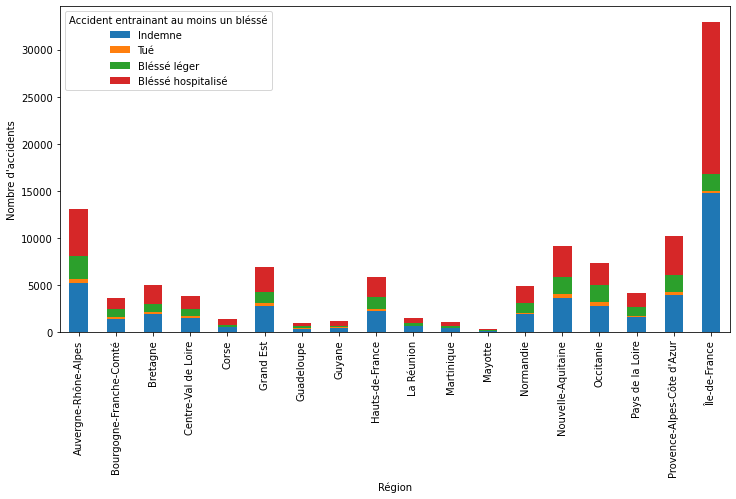

In [39]:


pd.crosstab(df_9['region_mapped'], df_9['grav_mapped']).plot(kind='bar', stacked=True, figsize=(12, 6))
#plt.title("Répartition des accidents par type de route et gravité")
plt.xlabel("Région")
plt.ylabel("Nombre d'accidents")
plt.legend(title="Accident entrainant au moins un bléssé")
plt.show()

In [40]:
df_9['age_victime']

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/pandas/io/formats/format.py:1405: FutureWarning:

Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/pandas/io/formats/format.py:1405: FutureWarning:

Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.



0         14.0
1         74.0
2         34.0
3         52.0
4         20.0
          ... 
126657    20.0
126658    18.0
126659    69.0
126660    30.0
126661    22.0
Name: age_victime, Length: 114836, dtype: category
Categories (104, float64): [0.0, 1.0, 2.0, 3.0, ..., 100.0, 101.0, 102.0, 109.0]

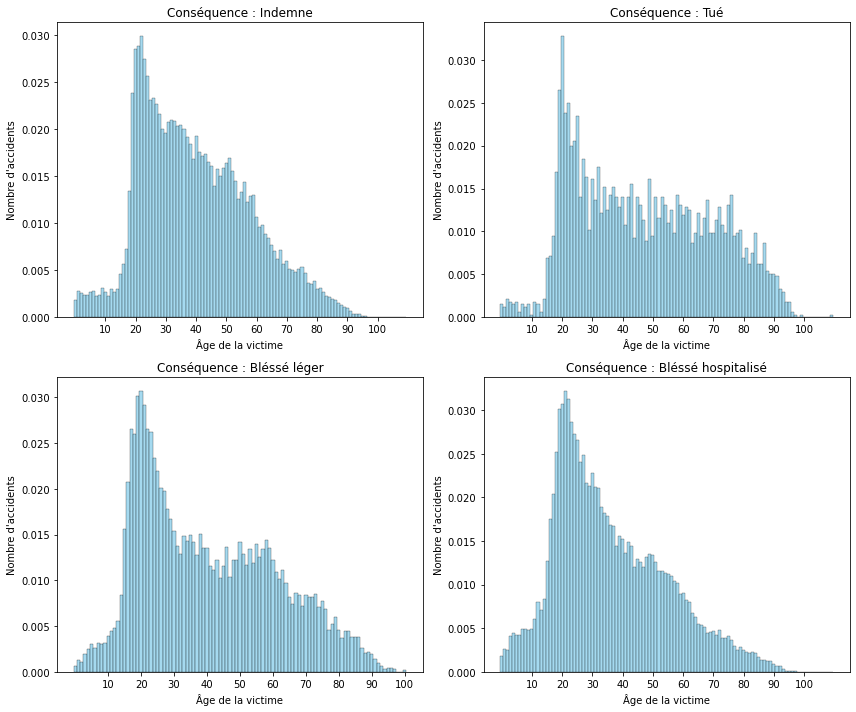

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=False, sharey=False)
axes = axes.flatten()

#df_filtered = df_9[df_9['age_victime'].astype('int64') >= 18]

# Boucle sur chaque type de gravité pour créer un histogramme
for i, (grav_code, grav_label) in enumerate(grav_mapping.items()):
    ax = axes[i]
    sns.histplot(df_9[df_9['grav'] == grav_code]['age_victime'],
                 stat='probability', 
                 bins= 20,
                 kde=False, ax=ax, color="skyblue")
    ax.set_title(f"Conséquence : {grav_label}")
    ax.set_xlabel("Âge de la victime")
    ax.set_ylabel("Nombre d'accidents")
    ax.set_xticks(np.arange(10, 110, 10))

# Ajustements et affichage
plt.tight_layout()
plt.show()

<AxesSubplot:>

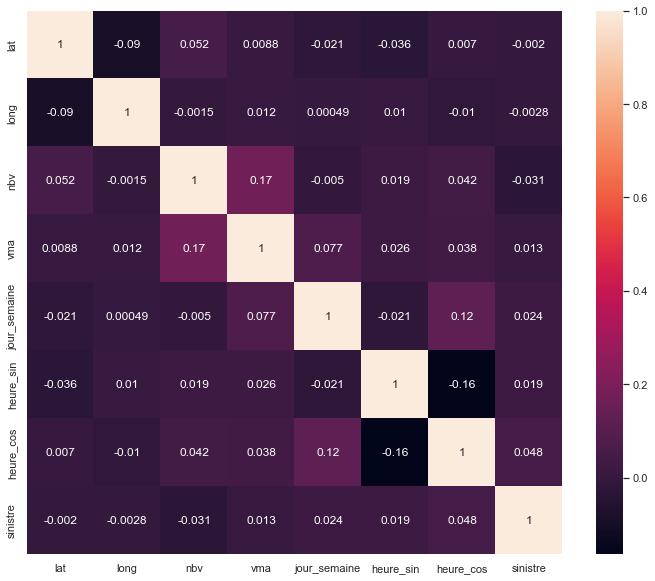

In [42]:
sns.set(rc={'figure.figsize':(12,10)})
sns.heatmap(df_10.corr(), annot=True)

# Machine Learning

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split, learning_curve, RandomizedSearchCV 
from sklearn.neural_network import MLPClassifier

In [79]:
num_col_ = ['lat', 'long', 'vma', 'nbv', 'heure_sin', 'heure_cos',
            'jour_semaine', 'age_victime']

cat_col_ = df_10.columns[~(df_10.columns.isin(num_col_ + ['sinistre', 'dep']))]

In [80]:
cat_col_

Index(['lum', 'int', 'atm', 'col', 'catr', 'circ', 'vosp', 'prof', 'plan',
       'surf', 'infra', 'situ', 'place', 'catu', 'sexe', 'trajet', 'secu1',
       'secu2', 'secu3', 'locp', 'actp', 'etatp', 'senc', 'catv', 'obs',
       'obsm', 'choc', 'manv', 'motor', 'atm_mapped'],
      dtype='object')

In [81]:
ord_encoder = OrdinalEncoder()

df_final = df_10.drop(columns=['dep'])

# #target = df_9['grav']

target = df_final[['sinistre']]
features = df_final.drop(columns=['sinistre'])
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=0)

preprocessor = ColumnTransformer(
     transformers=[
         ('num', 'passthrough', num_col_),
         ('cat', OneHotEncoder(handle_unknown= 'ignore' ), cat_col_ )
     ])

# Créer le pipeline

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

pipeline.fit(X_train)

# Transformer les deux ensembles (train et test) en utilisant le pipeline ajusté
X_train_sparse = pipeline.transform(X_train)
X_test_sparse = pipeline.transform(X_test)



In [82]:
## Random forest, XgBoost, SVM, Naive bayes  

In [83]:
def evaluation(model):
    model.fit(X_train_sparse, y_train)
    pred=model.predict(X_test_sparse)
    print(f"{model}")
    print (confusion_matrix(y_test, pred))
    print (classification_report(y_test, pred))

    N, train_score, val_score = learning_curve(model, X_train_sparse, y_train, cv= 4, 
                                               scoring= 'recall', 
                                               train_sizes= np.linspace(0.1, 1, 5))
    
    plt.figure(figsize=(12,8))
    plt.plot(N, train_score.mean(axis=1), label = 'train score')
    plt.plot(N, val_score.mean(axis=1), label = 'validation score')
    plt.legend()

In [84]:
X_train_sparse.shape
X_test_sparse.shape

(22295, 301)

<ipython-input-65-69508dd83a2e>:2: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



RandomForestClassifier(random_state=0)
[[ 7512  1933]
 [ 2358 10492]]
              precision    recall  f1-score   support

       False       0.76      0.80      0.78      9445
        True       0.84      0.82      0.83     12850

    accuracy                           0.81     22295
   macro avg       0.80      0.81      0.80     22295
weighted avg       0.81      0.81      0.81     22295



/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:593: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:593: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:593: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/model_selection/_validation.py:593: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y t

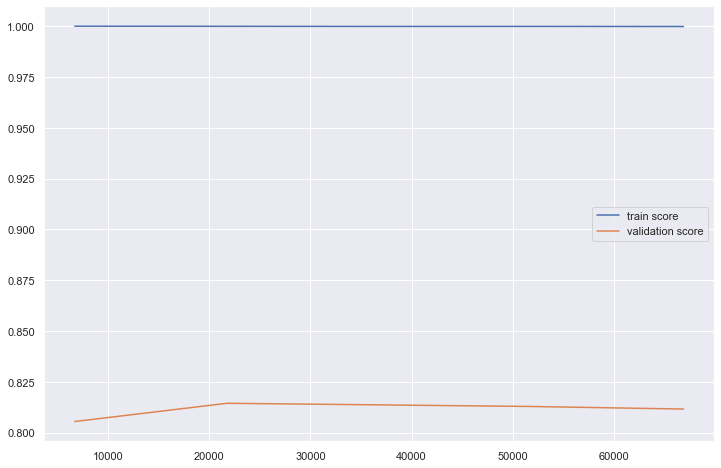

In [71]:
R_Forest = RandomForestClassifier(random_state=0)
evaluation(R_Forest)

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



SGDClassifier(random_state=0)
[[8312 1133]
 [4166 8684]]
              precision    recall  f1-score   support

       False       0.67      0.88      0.76      9445
        True       0.88      0.68      0.77     12850

    accuracy                           0.76     22295
   macro avg       0.78      0.78      0.76     22295
weighted avg       0.79      0.76      0.76     22295



/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



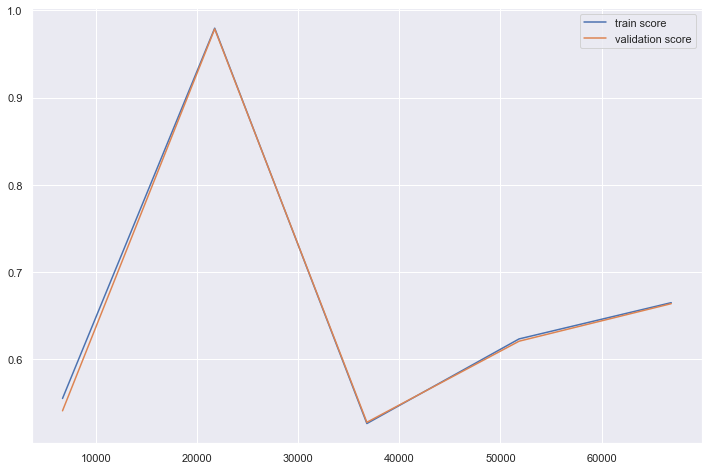

In [69]:
sgd= SGDClassifier(random_state=0)
evaluation(sgd)

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



GradientBoostingClassifier(random_state=0)
[[ 7201  2244]
 [ 2502 10348]]
              precision    recall  f1-score   support

       False       0.74      0.76      0.75      9445
        True       0.82      0.81      0.81     12850

    accuracy                           0.79     22295
   macro avg       0.78      0.78      0.78     22295
weighted avg       0.79      0.79      0.79     22295



/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



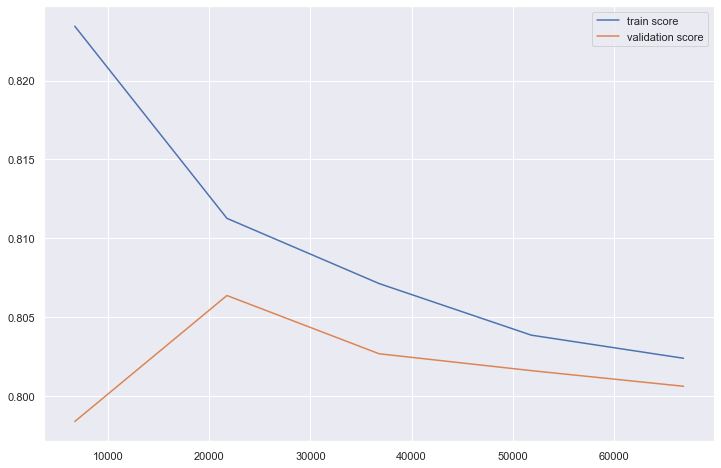

In [85]:
xg_boost = GradientBoostingClassifier(random_state=0)
evaluation(xg_boost)

In [86]:
param_distributions = {
    'n_estimators': np.arange(50, 300, 50),  # Nombre d'arbres
    'max_depth': np.arange(3, 10),           # Profondeur maximale de chaque arbre
    'learning_rate': np.linspace(0.01, 0.3, 10),  # learning rate    # Fraction d'échantillons pour chaque arbre
}

RSCV_xgboost = RandomizedSearchCV(
    estimator=xg_boost,
    param_distributions=param_distributions,
    n_iter=10,  # Nombre d'itérations aléatoires
    scoring='recall',  # Utilisez la métrique qui vous convient
    cv=2,  # Nombre de plis pour la validation croisée
    random_state=0,
    n_jobs=-1  # Utilise tous les cœurs disponibles pour la parallélisation
)

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



RandomizedSearchCV(cv=2, estimator=GradientBoostingClassifier(random_state=0),
                   n_jobs=-1,
                   param_distributions={'learning_rate': array([0.01      , 0.04222222, 0.07444444, 0.10666667, 0.13888889,
       0.17111111, 0.20333333, 0.23555556, 0.26777778, 0.3       ]),
                                        'max_depth': array([3, 4, 5, 6, 7, 8, 9]),
                                        'n_estimators': array([ 50, 100, 150, 200, 250])},
                   random_state=0, scoring='recall')
[[ 7306  2139]
 [ 2177 10673]]
              precision    recall  f1-score   support

       False       0.77      0.77      0.77      9445
        True       0.83      0.83      0.83     12850

    accuracy                           0.81     22295
   macro avg       0.80      0.80      0.80     22295
weighted avg       0.81      0.81      0.81     22295



/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



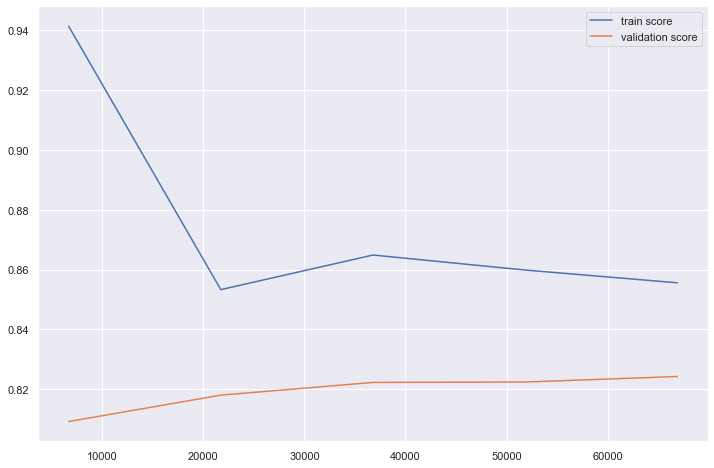

In [87]:
evaluation(RSCV_xgboost)

In [88]:
print(RSCV_xgboost.best_params_)

{'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.1711111111111111}


In [89]:
print(RSCV_xgboost.best_estimator_)

GradientBoostingClassifier(learning_rate=0.1711111111111111, max_depth=5,
                           n_estimators=250, random_state=0)


/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:614: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



MLPClassifier(hidden_layer_sizes=[64, 32, 16], max_iter=100, random_state=0)
[[ 7283  2162]
 [ 2784 10066]]
              precision    recall  f1-score   support

       False       0.72      0.77      0.75      9445
        True       0.82      0.78      0.80     12850

    accuracy                           0.78     22295
   macro avg       0.77      0.78      0.77     22295
weighted avg       0.78      0.78      0.78     22295



/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:614: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:614: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/Users/hugoseumen/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:63: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().

/Users/hugoseumen/opt/anaconda3/

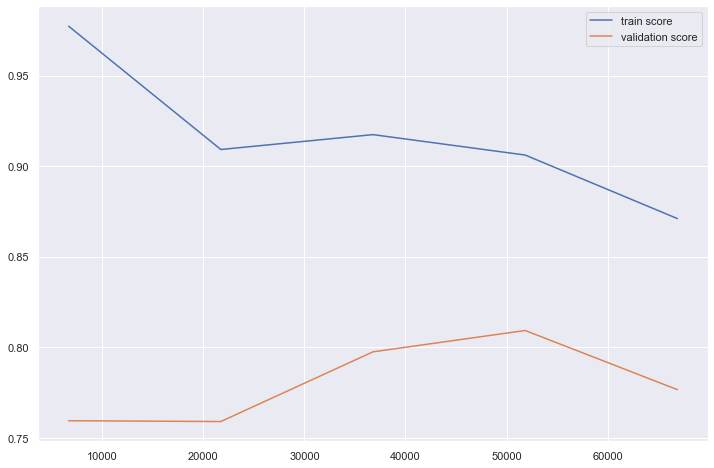

In [70]:
mlp = MLPClassifier(random_state=0, hidden_layer_sizes=[64, 32, 16], max_iter= 100)
evaluation(mlp)

In [90]:
# importances_rf = R_Forest.feature_importances_
importances_xg = xg_boost.feature_importances_
# importances_xg_rscv = RSCV_xgboost.feature_importances_




In [91]:
cat_col_names = pipeline.named_steps['preprocessor'].transformers_[1][1]
nom_col = cat_col_names.get_feature_names(cat_col_)

all_feature_names = list(num_col_) + list(cat_col_)

In [59]:
# feature_importances_rf = sorted(zip(all_feature_names, importances_rf), key=lambda x: x[1], reverse=True)

# # Afficher les colonnes les plus importantes
# for feature, importance in feature_importances_rf[:15]:  # Top 10 des colonnes
#     print(f"{feature}: {importance}")

In [92]:
feature_importances_xg = sorted(zip(all_feature_names, importances_xg), key=lambda x: x[1], reverse=True)

# Afficher les colonnes les plus importantes
for feature, importances in feature_importances_xg[:13]:  # Top 10 des colonnes
    print(f"{feature}: {importances}")

vma: 0.03092290425258787
manv: 0.012315213808326578
obsm: 0.010096586658392971
motor: 0.004536438801198714
age_victime: 0.0017772023037146522
choc: 0.00164459484274897
long: 0.0013663537880273296
heure_sin: 0.0010071458522510055
heure_cos: 0.0009919720377356018
lat: 0.000761725417074889
atm: 0.0005875091085736545
situ: 0.0005198677069275171
lum: 0.00024096085491934343


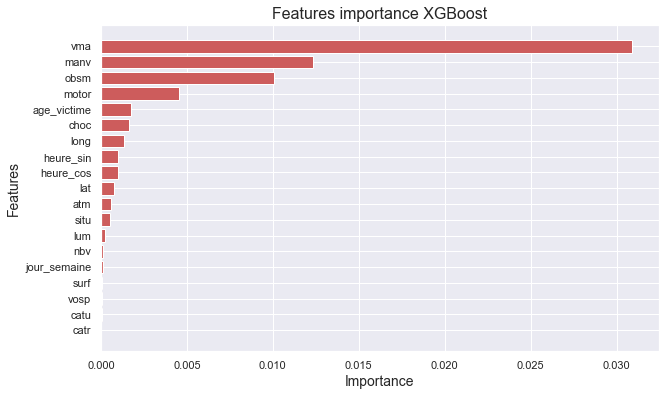

In [125]:
zip_importance = zip(all_feature_names, importances_xg)
col = ['Features', 'Importance']
importance_df = pd.DataFrame( zip_importance, columns= col).sort_values(by='Importance', ascending=False).loc[:12]

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Features'], importance_df['Importance'], color='indianred')
plt.title(f'Features importance XGBoost', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True)

plt.show()

